# DTAT331. deeptrack.sequences

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/3-advanced-topics/DTAT331_sequences.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

This advanced tutorial introduces the module [deeptrack.sequences](../../deeptrack/sequences.py).

## 1. What is `sequences.py`?

The `sequences.py` module in DeepTrack2 provides tools for constructing 
and manipulating sequential data, where each frame or element may 
depend on or interact with the previous ones. It introduces the `Sequence` 
class, which represents an ordered series of feature evaluations, and 
provides utilities for propagating and managing stateful or time-dependent 
information across frames. This is essential for simulating and analyzing 
dynamic systems—such as particle trajectories, evolving microscopy scenes, 
or time-series data—in a structured and reusable manner. The module is 
designed to integrate seamlessly with the rest of the DeepTrack feature 
graph architecture, while adding support for temporal logic and memory.

The key roles of `sequences.py` are:

- **Definition and Management of Temporal Sequences of Features:**
  The `Sequence` class allows users to construct an ordered list of 
  feature evaluations, where each frame can be independently generated 
  or depend on the previous ones.

- **Propagation of Sequential Data:**
  With `propagate_sequential_data`, state variables such as positions, 
  labels, or metadata can be passed forward through the sequence, 
  enabling coherent modeling of temporal dynamics.

- **Handling of Memory Across Time Steps:**
  Features can retain and update state across frames, making it possible 
  to model behaviors like drift, motion persistence, or object continuity 
  over time.

- **Generation of Synthetic Videos or Time Series:**
  Sequences provide a straightforward interface for generating batches 
  of temporally structured data, which is critical for training and 
  evaluating deep learning models on dynamic datasets.

- **Integration with the Core Feature Pipeline:**
  Sequence elements are just standard DeepTrack features, allowing 
  seamless integration with optical models, noise processes, and 
  detectors.

- **Customized Update Logic:**
  Users can inject custom logic to update state between frames, making 
  `sequences.py` a flexible tool for simulating complex evolving systems.

## 2. What is a Sequence?

Sequences are lists of (typically) images, where any image in the series may depend on previous images. They can be used to create videos. They can also be used to resolve the same feature several times, changing only a subset of the properties of the feature. An example is imaging a sample at several focal planes.

To resolve a sequence, you create an instance of the feature `Sequence` with the feature you want to resolve and `sequence_length` as parameters.

By default, properties remain constant so so that each step in the sequence is by default the same.

To make the properties change, you should call the method `myfeature.to_sequential()` for the feature you want to change during the sequence, and a set of functions as keyword arguments. These functions will be converted to instances of `SequentialProperty`, which behave similarly to regular properties.

For more information about how sequential properties work, see [DTAT311_properties.ipynb](DTAT311_properties.ipynb).

## 3. Example - A Rotating Ellipse

To demonstrate the concept of `sequences`, we will implement a simple case of a rotating ellipse.

Define the optical device ...

In [2]:
from deeptrack.optical.optics import Fluorescence

optics = Fluorescence(
    NA=0.6,
    magnification=10,
    resolution=1e-6,
    wavelength=633e-9,
    output_region=(0, 0, 32, 32),
)

... define the elliptical scatterer with initial rotation value ...

In [3]:
from deeptrack.optical.scatterers import Ellipse

ellipse = Ellipse(
    position_unit="pixel",
    position=(16, 16),
    intensity=1,
    radius=(1.5e-6, 1e-6),
    rotation=0,  # Rotation at time 0
)

... define the function to get the next rotation value ...

In [4]:
import numpy as np


def update_rotation(sequence_length, previous_value):
    delta = 2 * np.pi / sequence_length
    next_value = previous_value + delta
    return next_value

... make the scatterer sequential by specifying the properties to be sequentially evaluated as arguments in `ellipse.to_sequential()` (for this case, it is the rotation of the ellipse) ...

In [5]:
rotating_ellipse = ellipse.to_sequential(rotation=update_rotation)

... image the sequential ellipse with the microscope ...

In [6]:
imaged_rotating_ellipse = optics(rotating_ellipse)

... encapsulate as a `Sequence` object and specify the sequence length ...

In [7]:
from deeptrack.sequences import Sequence

imaged_rotating_ellipse_sequence = Sequence(
    imaged_rotating_ellipse,
    sequence_length=50,
)

... and finally image the rotating ellipse.

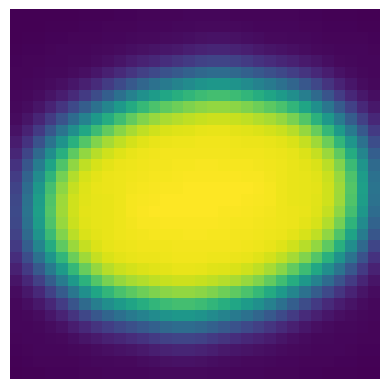

In [8]:
imaged_rotating_ellipse_sequence.update().plot();

## 4. Example - Brownian Motion

A more advanced application of `sequences` is to simulate a video of the Brownian motion of a microscopic particle.

Define the optical device ...

In [9]:
optics = Fluorescence(
    NA=0.6,
    magnification=10,
    resolution=1e-6,
    wavelength=633e-9,
    output_region=(0, 0, 32, 32),
)

... define a scatterer (in this case, a microscopic sphere) with its initial position ...


In [10]:
from deeptrack.optical.scatterers import Sphere

particle = Sphere(
    position_unit="pixel",
    position=(16, 16),  # Position at time 0
    radius=(0.1e-6),
    intensity=1,
)

... define a function to update the scatterer's position property with normally distributed perturbations ...

In [11]:
def update_position(sequence_length, previous_value):
    delta = np.random.standard_normal(2)
    next_value = previous_value + delta
    return next_value

... make the scatterer sequential by specifying the properties to be sequentially evaluated as arguments in `particle.to_sequential()` (for this case, it is the position of the scatterer) ...

In [12]:
brownian_particle = particle.to_sequential(position=update_position)

... image the Brownian particle with the microscope ...

In [13]:
imaged_brownian_particle = optics(brownian_particle)

... encapsulate as a `Sequence` object and specify the sequence length ...

In [14]:
imaged_brownian_particle_sequence = Sequence(
    imaged_brownian_particle,
    sequence_length=100,
)

... and finally image the Brownian particle.

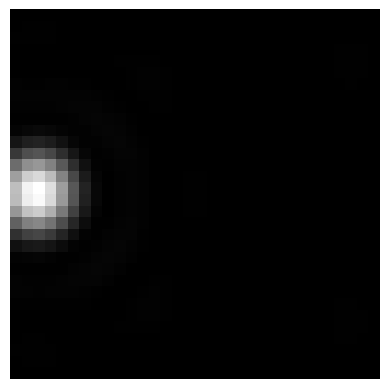

In [15]:
imaged_brownian_particle_sequence.update().plot(cmap="gray");

### 4.1 Simulating Multiple Brownian Particles

You can also use the chain operator when imaging the brownian particle as a sequence. This will produce a set of scatterers that are updated independently of each other.

Chain multiple particles with `^` ...

In [16]:
imaged_brownian_particles = optics(brownian_particle ^ 10)

... encapsulate as a `Sequence` object and specify the sequence length ...

In [17]:
imaged_brownian_particles_sequence = Sequence(
    imaged_brownian_particles,
    sequence_length=100,
)

... and finally image the ensemble of Brownian particles.

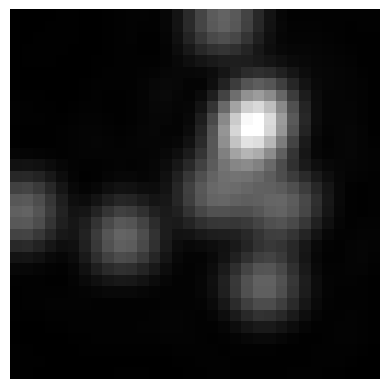

In [18]:
imaged_brownian_particles_sequence.update().plot(cmap="gray");

## 5. Example - A Microscope Sequence

Sequences are not exclusive to scatterers. You can evaluate sequentially the properties of any feature in DeepTrack2, including microscopes. This example will show how you can vary the wavelength property.

Deafine a microscope ...

In [19]:
from deeptrack.optical.optics import Brightfield


optics = Brightfield(
    NA=0.6,
    magnification=10,
    resolution=1e-6,
    wavelength=400e-9,  # Initial wavelength at time step 0
    output_region=(0, 0, 128, 128),
)

... define a scatterer ...

In [20]:
particle = Sphere(
    position_unit="pixel",
    position=(64, 64),
    radius=(1e-6),
    refractive_index=1.5,
)

... define function to update the microscope wavelength with constant increments ...

In [21]:
def update_wavelength(sequence_length, previous_value):
    delta = 5e-9  # nm
    next_value = previous_value + delta
    return next_value

... make the microscope sequential by specifying the properties to be sequentially evaluated as arguments in `optics.to_sequential()` (for this case, it is the wavelength of the illuminating light) ...

In [22]:
microscope_sequence = optics.to_sequential(wavelength=update_wavelength)

... image the particle with the microscope ...

In [23]:
variable_microscope = optics(particle)

... encapsulate as a `Sequence` object and specify the sequence length ...

In [24]:
imaged_microscope_sequence = Sequence(
    variable_microscope,
    sequence_length=100,
)

... and finally observe the image of the scatterer as the wavelegth varies.

/Users/giovannivolpe/Documents/GitHub/DeepTrack2/deeptrack/optical/optics.py:1878: UserWarning: Brightfield imaging from ScatteredVolume assumes a weak-phase / projection approximation. Use ScatteredField for physically accurate brightfield simulations.
  warnings.warn(


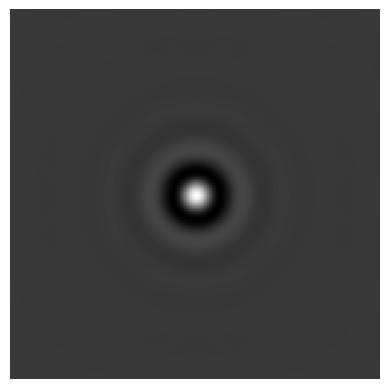

In [25]:
imaged_microscope_sequence.update().plot(cmap="gray");